In [51]:
import sys
sys.path.append("../../src")
from equilibrium_critical_correlations import *
from kblock_ising_model import U, k_vals
from kblock_ising_model import P_n as Pk
from kblock_ising_model import PZ_n as Pz
from common_imports import *
from time import time

In [80]:
Ls = [14]
ns = np.arange(1,15)
Xp= []
Zp=[]
for L in tqdm(Ls):
    Dat= []
    Dat2=[]
    k0 = k_vals(L)
    U0 = U(k0,1)
    for n in ns:
        Dat2.append(Pz(n,U0,k0))
        Dat.append( Pk(n,U0,k0))
    Xp.append(np.array(Dat))
    Zp.append(np.array(Dat2))


  0%|          | 0/1 [00:00<?, ?it/s]/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/Compare_Z_X_projectors/../../src/kblock_ising_model.py:170: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = -D(Nd,T,k)
/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/Compare_Z_X_projectors/../../src/kblock_ising_model.py:146: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,T,k)
100%|██████████| 1/1 [00:17<00:00, 17.34s/it]


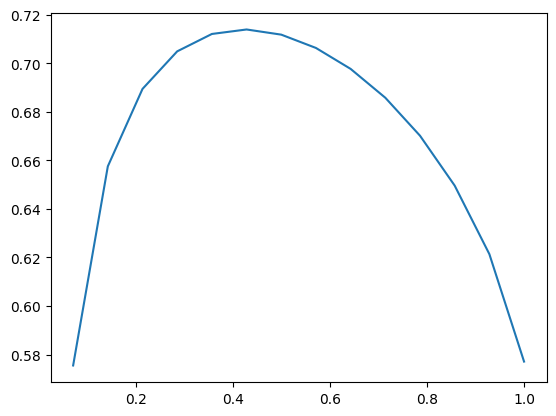

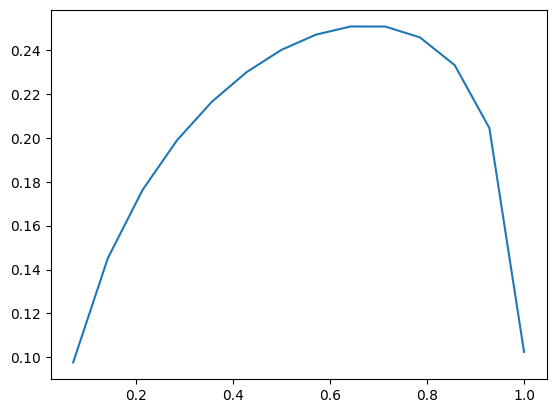

In [96]:
for d,L in zip(Xp,Ls):

    P_scaled = -log(d)-ns/8.5
    plot(ns/max(ns), P_scaled, label=f"L={L}")

show()
for d,L in zip(Zp,Ls):

    P_scaled = -log(d)-ns/9.8
    plot(ns/max(ns), P_scaled, label=f"L={L}")



In [2]:
n = np.arange(1,21,1)

P = array([P_n(ni) for ni in n])


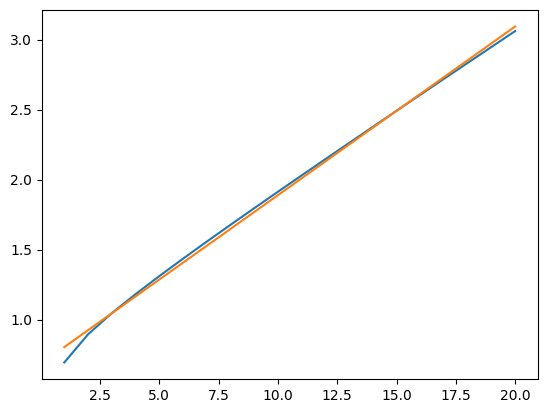

In [13]:
#scatter((n),log(2*P))

def linear(x,b,m):
    return m*x+b

def exp_fit(x,a,b):
    return a*exp(b*x)

import scipy.optimize as opt

#plot(n,P)

fit = opt.curve_fit(linear,n,-log(P))

plot(n,-log(P))
plot(n,linear(n,*fit[0]))

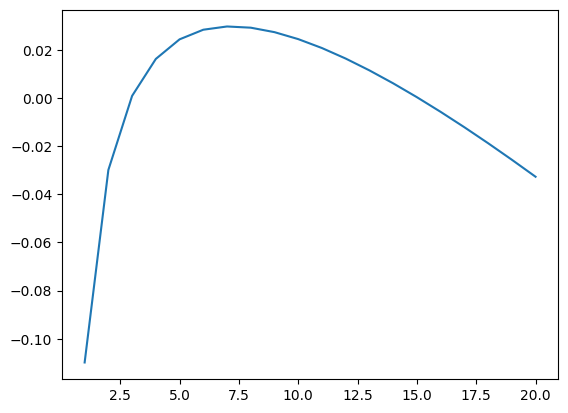

In [14]:
plot(n,-log(P)-linear(n,*fit[0]))

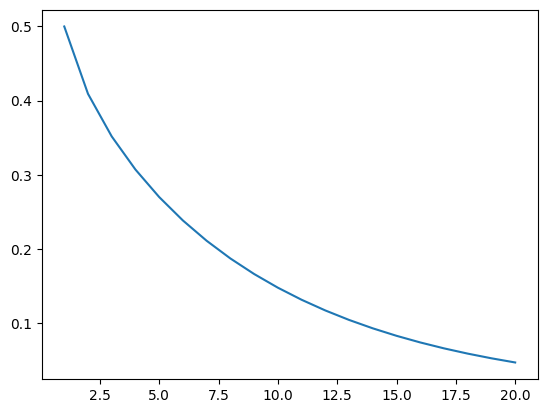

In [32]:
y= P
plot(n,y)
#ylim(0,.6)

In [98]:
import numpy as np

def projector_probability(l, L):
    """
    Compute P_p = det_{1 <= i,j <= l} [ δ_ij/2 + (1/(2L)) * csc(pi(i-j+1/2)/L) ]

    Parameters
    ----------
    l : int
        Block length (ℓ in the formula).
    L : int
        System size.

    Returns
    -------
    float
        Value of P_p.
    """
    # Build the matrix
    M = np.zeros((l, l), dtype=np.complex128)
    for i in range(l):
        for j in range(l):
            delta = 1.0 if i == j else 0.0
            angle = np.pi * (i - j + 0.5) / L
            M[i, j] = delta/2 + (1/(2*L)) * (1/np.sin(angle))
    
    # Determinant
    return np.linalg.det(M).real  # result should be real

# Example

l = np.arange(1,100)
x= [(projector_probability(li, L=100000)) for li in l]


/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


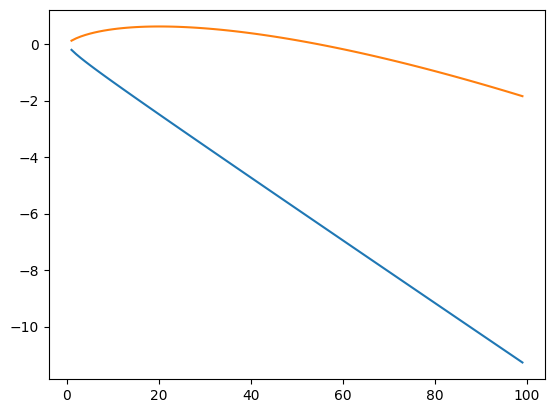

In [111]:
plot(l,log(x))
plot(l,l*(1/8-log(l)/32))

In [3]:
from equilibrium_z_projectors import *

[0.00712904 0.00143431]


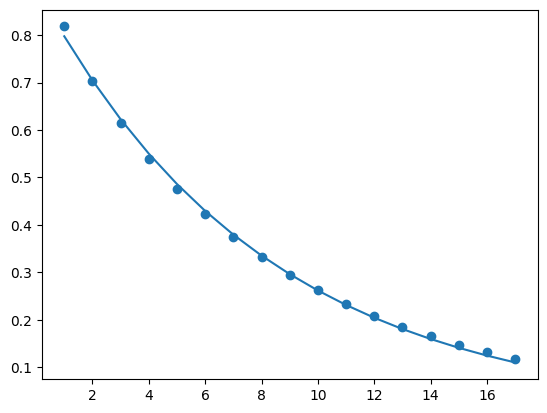

In [ ]:
import scipy.optimize


n = np.arange(1,18)
x= array([P_n(i) for i in n])

fit = scipy.optimize.curve_fit(exp_fit,n,x)
print(np.sqrt(np.diag(fit[1])))
plot(n,exp_fit(n,*fit[0]))
scatter(n,x)

[2.99315356e-04 5.53861707e-05]


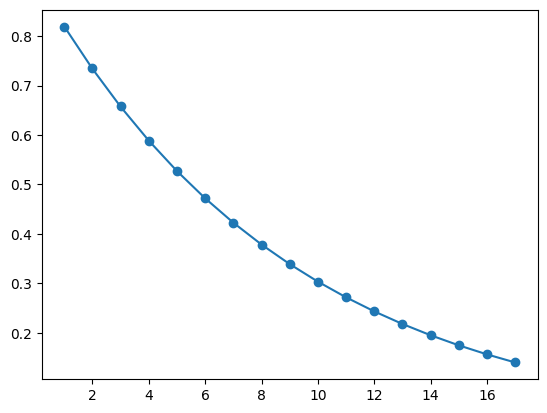

In [34]:
fit = scipy.optimize.curve_fit(exp_fit,n,x*n**(1/16))
print(np.sqrt(np.diag(fit[1])))
plot(n,exp_fit(n,*fit[0]))
scatter(n,x*n**(1/16))

In [55]:
print(fit)

(array([ 0.91483566, -0.11028108]), array([[ 8.95896824e-08, -1.30289294e-08],
       [-1.30289294e-08,  3.06762791e-09]]))


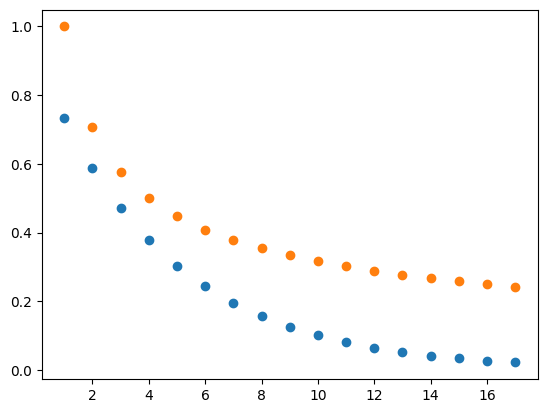

In [54]:
scatter(n,x*n**(1/16)*exp(n*fit[0][1]))
scatter(n,1/sqrt(n))

In [46]:
exp_fit(10,1,0)

np.float64(1.0)

In [46]:
import kblock_ising_model as kb


In [51]:
k0 = kb.k_vals(14)
U0 = kb.U(k0,1)
n = np.arange(1,14)

x= array([kb.PZ_n(i,U0,k0) for i in n])


[ 0.89231706 -0.11717446]
[0.01219983 0.00266114]


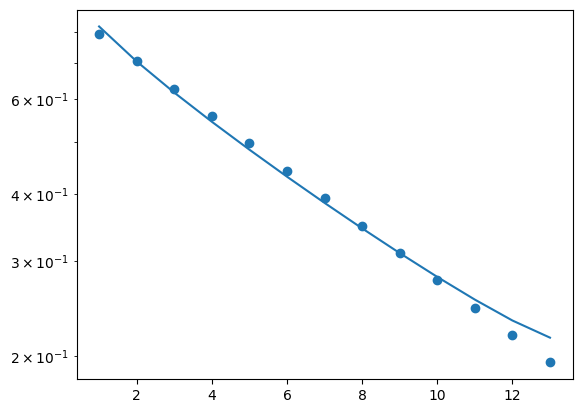

In [52]:
plot(n,x)

fit= scipy.optimize.curve_fit(exp_fit,n,x)

print(fit[0])
scatter(n,exp_fit(n,*fit[0]))
yscale("log")

print(sqrt(np.diag(fit[1])))